In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df_fraud = pd.read_csv(url)

print(f"Toplam Satır Sayısı: {df_fraud.shape[0]}")
print(f"Toplam Sütun Sayısı: {df_fraud.shape[1]}")

df_fraud.head()

Toplam Satır Sayısı: 284807
Toplam Sütun Sayısı: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


gerçek insanların kredi kartı harcamaları olduğu için PCA ile veri şifrelemiş.

Normal İşlemler (0): 284315
Dolandırıcılık (1): 492


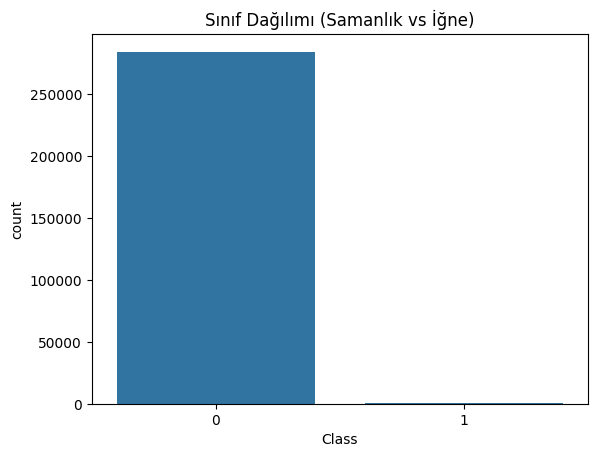

In [5]:
counts = df_fraud['Class'].value_counts()
print("Normal İşlemler (0):", counts[0])
print("Dolandırıcılık (1):", counts[1])

sns.countplot(x='Class', data=df_fraud)
plt.title('Sınıf Dağılımı (Samanlık vs İğne)')
plt.show()

Sınıf Dengesizliği

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_fraud.drop(['Class', 'Time'], axis=1)
y = df_fraud['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Eğitim seti boyutu:", X_train.shape)
print("Test setindeki dolandırıcı sayısı:", y_test.sum())

Eğitim seti boyutu: (227845, 29)
Test setindeki dolandırıcı sayısı: 98


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE öncesi '1' sayısı:", y_train.sum())
print("SMOTE sonrası '1' sayısı:", y_train_smote.sum())
print("SMOTE sonrası toplam eğitim satırı:", len(y_train_smote))

SMOTE öncesi '1' sayısı: 394
SMOTE sonrası '1' sayısı: 227451
SMOTE sonrası toplam eğitim satırı: 454902


Veri seti çok dengesiz (Fraud oranı %0.17). Modeli eğitmek için SMOTE ile sentetik veri ürettim, yoksa model her şeye 'temiz' der.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model_fraud = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Model eğitiliyor, lütfen bekleyin...")
model_fraud.fit(X_train_smote, y_train_smote)
print("Eğitim tamamlandı!")

y_pred_fraud = model_fraud.predict(X_test)

print("\n--- DOLANDIRICILIK TESPİT RAPORU ---")
print(classification_report(y_test, y_pred_fraud))

Model eğitiliyor, lütfen bekleyin...
Eğitim tamamlandı!

--- DOLANDIRICILIK TESPİT RAPORU ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



Benim için asıl başarı metriği F1-Score (%85) ve Recall (%83) değerleridir, çünkü verim aşırı dengesiz

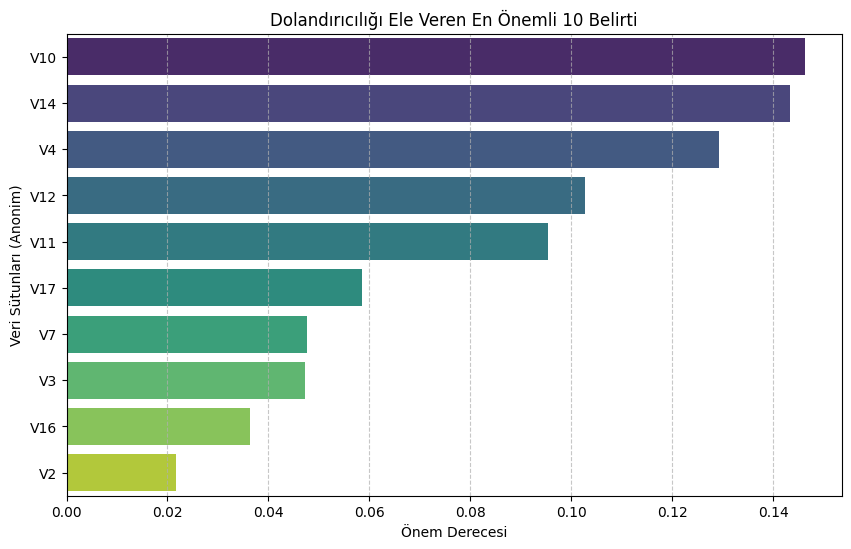

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importances = model_fraud.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Önem', ascending=False).head(10)


plt.figure(figsize=(10, 6))

sns.barplot(x='Önem', y='Özellik', data=feature_importance_df, hue='Özellik', palette='viridis', legend=False)

plt.title('Dolandırıcılığı Ele Veren En Önemli 10 Belirti')
plt.xlabel('Önem Derecesi')
plt.ylabel('Veri Sütunları (Anonim)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import joblib

joblib.dump(model_fraud, 'fraud_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("Model ve Scaler başarıyla 'diske' kaydedildi!")

In [ ]:
import numpy as np
import pandas as pd
import joblib

loaded_model = joblib.load('fraud_model.joblib')


yeni_islem = np.random.randn(1, 29) 


yeni_islem_df = pd.DataFrame(yeni_islem, columns=X.columns)

tahmin_olasiligi = loaded_model.predict_proba(yeni_islem_df)
tahmin_sinifi = loaded_model.predict(yeni_islem_df)


print(f"Üretilen Veri Şekli: {yeni_islem_df.shape}")
print(f"İşlemin Dolandırıcılık Olasılığı: %{tahmin_olasiligi[0][1]*100:.2f}")
print(f"Model Kararı: {'TEHLİKELİ!' if tahmin_sinifi[0] == 1 else 'TEMİZ'}")

In [ ]:
from fastapi import FastAPI
import joblib
import pandas as pd
import uvicorn
from pydantic import BaseModel
import nest_asyncio

nest_asyncio.apply()

app = FastAPI(title="Real-Time Fraud API")
loaded_model = joblib.load('fraud_model.joblib')

class Transaction(BaseModel):
    features: list  

@app.get("/")
def home():
    return {"durum": "Sistem Ayakta", "mesaj": "Fraud API'sine Hoş Geldiniz!"}

@app.post("/predict")
def predict_fraud(transaction: Transaction):
    df = pd.DataFrame([transaction.features], columns=loaded_model.feature_names_in_)
   
    prob = loaded_model.predict_proba(df)[0][1]
    prediction = int(loaded_model.predict(df)[0])
    
    return {
        "is_fraud": prediction,
        "fraud_probability": f"%{prob*100:.2f}",
        "action": "BLOKE ET" if prediction == 1 else "ONAYLA"
    }

import asyncio

if __name__ == "__main__":
    config = uvicorn.Config(app, host="127.0.0.1", port=8000, loop="asyncio")
    server = uvicorn.Server(config)
    
    loop = asyncio.get_event_loop()
    if loop.is_running():
        loop.create_task(server.serve())
        print("Sunucu Jupyter içinde BAŞLATILDI!")
        print("Adres: http://127.0.0.1:8000/docs")
    else:
        loop.run_until_complete(server.serve())

Modeli sadece analizde bırakmamak için API haline getirdim. Flask yerine daha hızlı olduğu için FastAPI tercih ettim

İlk denemede Scaler'ı unutmuştum, tahminler yanlış çıktı. API içine scaler.transform ekleyerek düzelttim

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model_fraud.predict(X_test)


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dürüst', 'Hırsız'])
fig, ax = plt.subplots(figsize=(8, 6)) # Grafiğin boyutunu ayarla
disp.plot(cmap=plt.cm.Blues, ax=ax)


plt.title("Credit Card Fraud - Model Başarı Tablosu", fontsize=14)
plt.tight_layout()

plt.savefig('confusion_matrix.png', dpi=300)
plt.show()